# MNIST Classification with scikit-learn `MLPClassifier`
## Instructor Version

This notebook demonstrates image classification using a **fully connected neural network (FNN)** implemented by scikit-learn's `MLPClassifier`.

MNIST is well suited for this purpose because each image is a simple grayscale handwritten digit.

Expected folder structure:

```text
your_notebook_folder/
│
├── MNIST_MLPClassifier_Instructor.ipynb
└── MNIST_Data/
    ├── x_train.npy
    ├── y_train.npy
    ├── x_test.npy
    └── y_test.npy
```

Each MNIST image has shape

\[
28 \times 28.
\]

Before passing an image to `MLPClassifier`, we flatten it into

\[
28 \times 28 = 784
\]

input features.


## Step 0: Import libraries

This notebook uses NumPy, Matplotlib, and scikit-learn only.

TensorFlow is not required.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    log_loss,
)

# Fix the random seed so that the results are reproducible.
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## Step 1: Load the local MNIST NumPy files

The original MNIST training set contains 60,000 images and the test set contains 10,000 images.

### Important note about labels

In TensorFlow/Keras, labels are often converted into one-hot vectors.

For example, digit 3 might become:

```text
[0, 0, 0, 1, 0, 0, 0, 0, 0, 0]
```

For scikit-learn's `MLPClassifier`, this is unnecessary for standard multiclass classification.

We therefore keep the labels as integers:

```text
0, 1, 2, ..., 9
```


In [4]:
# Folder containing the local MNIST NumPy files.
mnist_path = "./MNIST_Data/"

# Load the training images.
# Expected shape: (60000, 28, 28)
train_data = np.load(mnist_path + "x_train.npy").astype(np.float32)

# Normalize the pixel values using the same transformation as in the provided code:
# original pixel range [0, 255]
# -> divide by 255 gives [0, 1]
train_data = train_data / 255.0

# Add a channel dimension so that each grayscale image has shape (28, 28, 1).
# This is not required by MLPClassifier, but it keeps the image representation explicit.
train_data = train_data.reshape(-1, 28, 28, 1)

# Load the training labels and keep them as integer class IDs.
train_labels = np.load(mnist_path + "y_train.npy").reshape(-1).astype(int)

# Load and normalize the test images in the same way.
test_data = np.load(mnist_path + "x_test.npy").astype(np.float32)
test_data = test_data / 255.0
test_data = test_data.reshape(-1, 28, 28, 1)

# Load the test labels as integer class IDs.
test_labels = np.load(mnist_path + "y_test.npy").reshape(-1).astype(int)

class_names = [str(i) for i in range(10)]

print("Training data shape:", train_data.shape)
print("Training labels shape:", train_labels.shape)
print("Test data shape:", test_data.shape)
print("Test labels shape:", test_labels.shape)
print("Unique class labels:", np.unique(train_labels))


Training data shape: (60000, 28, 28, 1)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28, 1)
Test labels shape: (10000,)
Unique class labels: [0 1 2 3 4 5 6 7 8 9]


In [8]:
train_data[0][14]

array([[0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.31764707],
       [0.9411765 ],
       [0.99215686],
       [0.99215686],
       [0.46666667],
       [0.09803922],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ],
       [0.        ]], dtype=float32)

## Step 2: Visualize sample images

Because the pixel values are currently in `[-0.5, 0.5]`, we add `0.5` before displaying them.

Matplotlib then receives image values approximately in `[0, 1]`.


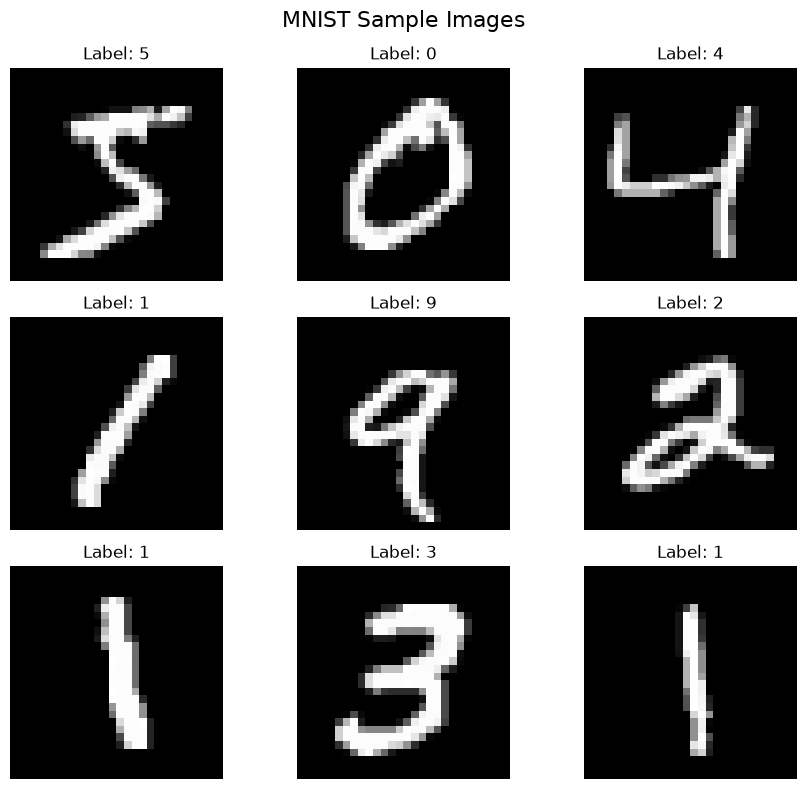

In [3]:
plt.figure(figsize=(9, 8))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    # Remove the final channel dimension:
    # (28, 28, 1) -> (28, 28)
    image = train_data[i].squeeze()

    # Reverse the shift for display:
    # [-0.5, 0.5] -> [0, 1]
    display_image = image

    plt.imshow(display_image, cmap="gray")
    plt.title(f"Label: {train_labels[i]}")
    plt.axis("off")

plt.suptitle("MNIST Sample Images", fontsize=16)
plt.tight_layout()
plt.show()


## Step 3: Flatten each image

`MLPClassifier` expects a two-dimensional feature matrix:

```text
(number_of_samples, number_of_features)
```

Each MNIST image has shape

\[
28 \times 28 \times 1.
\]

Therefore, each image is flattened into

\[
784
\]

features.


In [4]:
# Save the image shape for later visualization.
image_shape = train_data.shape[1:]   # (28, 28, 1)

# Flatten each image:
# (n, 28, 28, 1) -> (n, 784)
X_train_full = train_data.reshape(train_data.shape[0], -1)
X_test = test_data.reshape(test_data.shape[0], -1)

# Use conventional X/y variable names.
y_train_full = train_labels
y_test = test_labels

print("Flattened training shape:", X_train_full.shape)
print("Flattened test shape:", X_test.shape)
print("Number of features per image:", X_train_full.shape[1])


Flattened training shape: (60000, 784)
Flattened test shape: (10000, 784)
Number of features per image: 784


## Step 4: Create a validation set

MNIST already provides a separate test set.

We therefore keep the original test set untouched and split the original training set into:

- training data,
- validation data.

The validation set helps us evaluate the model during development without using the test set.


In [5]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_train_full
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)


Training set: (48000, 784) (48000,)
Validation set: (12000, 784) (12000,)
Test set: (10000, 784) (10000,)


## Step 5: Build the neural network

We use one hidden layer with 128 neurons.

The network structure is approximately:

```text
784 inputs -> 128 hidden neurons -> 10 output classes
```

`MLPClassifier` automatically creates the output layer for the 10 classes.


In [6]:
model = MLPClassifier(
    hidden_layer_sizes=(128,),   # One hidden layer containing 128 neurons.
    activation="relu",           # ReLU activation in the hidden layer.
    solver="adam",               # Adam optimizer.
    alpha=0.0001,                # L2 regularization strength.
    batch_size=64,               # Mini-batch size.
    learning_rate_init=0.001,    # Initial learning rate.
    max_iter=30,                 # Maximum number of training epochs.
    shuffle=True,                # Shuffle training samples before each epoch.
    random_state=RANDOM_STATE,   # Reproducible initialization and shuffling.
    verbose=True,                # Print training progress.
    early_stopping=True,         # Stop if validation performance stops improving.
    validation_fraction=0.10,    # Internal validation subset for early stopping.
    n_iter_no_change=5           # Stop after 5 epochs without sufficient improvement.
)

print(model)


MLPClassifier(batch_size=64, early_stopping=True, hidden_layer_sizes=(128,),
              max_iter=30, n_iter_no_change=5, random_state=42, verbose=True)


## Step 6: Train the model

`fit()` performs the whole learning procedure:

1. forward propagation,
2. loss computation,
3. backpropagation,
4. weight updates using Adam.


In [7]:
model.fit(X_train, y_train)

print("\nNumber of completed epochs:", model.n_iter_)
print("Final training loss:", model.loss_)


Iteration 1, loss = 0.35306303
Validation score: 0.940000
Iteration 2, loss = 0.16693278
Validation score: 0.957500
Iteration 3, loss = 0.11717143
Validation score: 0.967500
Iteration 4, loss = 0.08905570
Validation score: 0.970000
Iteration 5, loss = 0.06939157
Validation score: 0.974375
Iteration 6, loss = 0.05608916
Validation score: 0.975625
Iteration 7, loss = 0.04467872
Validation score: 0.970000
Iteration 8, loss = 0.03741669
Validation score: 0.975833
Iteration 9, loss = 0.03052280
Validation score: 0.976875
Iteration 10, loss = 0.02552743
Validation score: 0.977083
Iteration 11, loss = 0.02125992
Validation score: 0.978333
Iteration 12, loss = 0.01707636
Validation score: 0.978542
Iteration 13, loss = 0.01449798
Validation score: 0.978333
Iteration 14, loss = 0.01254267
Validation score: 0.979167
Iteration 15, loss = 0.01060568
Validation score: 0.978542
Iteration 16, loss = 0.00978429
Validation score: 0.976667
Iteration 17, loss = 0.01141694
Validation score: 0.978333
Iterat

D:\Others\Program_Files\Anaconda3\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


## Step 7: Plot the training loss


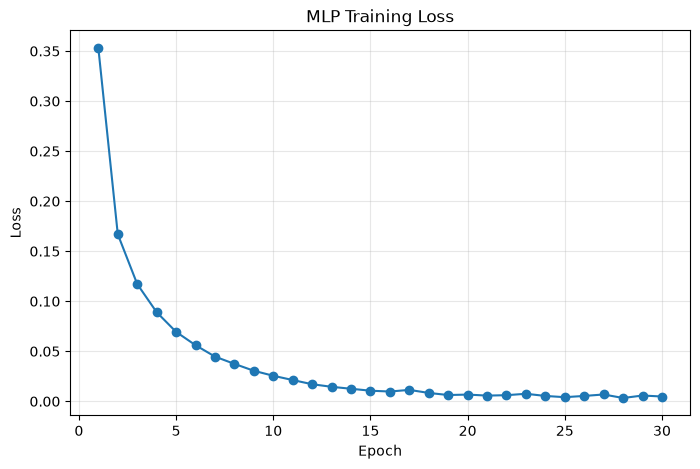

In [8]:
plt.figure(figsize=(8, 5))

plt.plot(
    range(1, len(model.loss_curve_) + 1),
    model.loss_curve_,
    marker="o"
)

plt.title("MLP Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(alpha=0.3)

plt.show()


## Step 8: Plot internal validation accuracy

Because `early_stopping=True`, scikit-learn keeps a small internal validation subset.

`validation_scores_` stores the validation accuracy after each epoch.


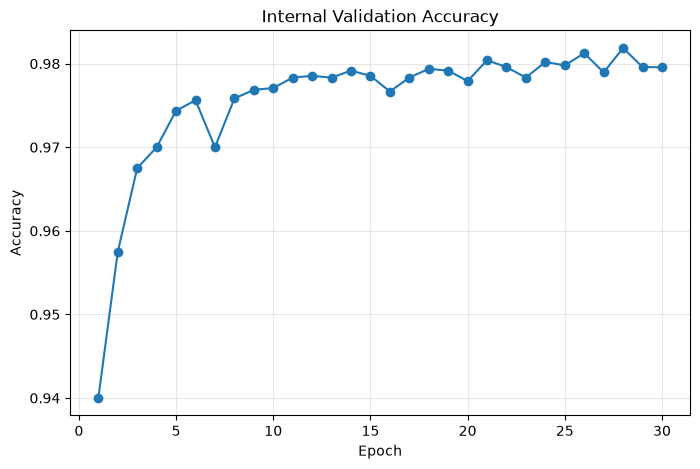

In [9]:
if hasattr(model, "validation_scores_") and model.validation_scores_ is not None:
    plt.figure(figsize=(8, 5))

    plt.plot(
        range(1, len(model.validation_scores_) + 1),
        model.validation_scores_,
        marker="o"
    )

    plt.title("Internal Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.grid(alpha=0.3)

    plt.show()


## Step 9: Evaluate on the separate validation set


In [10]:
# Predict class labels.
y_val_pred = model.predict(X_val)

# Predict class probabilities.
y_val_prob = model.predict_proba(X_val)

val_accuracy = accuracy_score(y_val, y_val_pred)
val_loss = log_loss(y_val, y_val_prob, labels=model.classes_)

print(f"Validation accuracy: {val_accuracy:.4f}")
print(f"Validation log loss: {val_loss:.4f}")


Validation accuracy: 0.9773
Validation log loss: 0.1125


## Step 10: Evaluate on the original MNIST test set


In [11]:
y_test_pred = model.predict(X_test)
y_test_prob = model.predict_proba(X_test)

test_accuracy = accuracy_score(y_test, y_test_pred)
test_loss = log_loss(y_test, y_test_prob, labels=model.classes_)

print(f"Test accuracy: {test_accuracy:.4f}")
print(f"Test log loss: {test_loss:.4f}")


Test accuracy: 0.9792
Test log loss: 0.0995


### Classification report

The classification report shows precision, recall, and F1-score for each digit.


In [12]:
print(
    classification_report(
        y_test,
        y_test_pred,
        target_names=class_names,
        digits=4
    )
)


              precision    recall  f1-score   support

           0     0.9779    0.9918    0.9848       980
           1     0.9903    0.9921    0.9912      1135
           2     0.9816    0.9835    0.9826      1032
           3     0.9792    0.9812    0.9802      1010
           4     0.9835    0.9735    0.9785       982
           5     0.9831    0.9787    0.9809       892
           6     0.9770    0.9770    0.9770       958
           7     0.9737    0.9718    0.9727      1028
           8     0.9752    0.9702    0.9727       974
           9     0.9693    0.9703    0.9698      1009

    accuracy                         0.9792     10000
   macro avg     0.9791    0.9790    0.9790     10000
weighted avg     0.9792    0.9792    0.9792     10000



## Step 11: Prediction demonstration

For one selected test image, we:

1. display the handwritten digit,
2. obtain the predicted class probabilities,
3. choose the class with the highest probability,
4. show the predicted digit and confidence.


In [13]:
def predict_sample(idx):
    """Display one MNIST test image and the model prediction."""

    # Get one flattened normalized sample.
    flat_sample = X_test[idx]

    # Predict the probability of each digit class.
    probabilities = model.predict_proba(
        flat_sample.reshape(1, -1)
    )[0]

    # Select the class with the highest probability.
    predicted_class = model.classes_[np.argmax(probabilities)]

    # True digit.
    true_class = y_test[idx]

    # Convert the flattened vector back to image form.
    normalized_image = flat_sample.reshape(image_shape).squeeze()

    # Reverse the shift:
    # [-0.5, 0.5] -> [0, 1]
    display_image = normalized_image + 0.5

    confidence = np.max(probabilities)

    plt.figure(figsize=(4, 4))
    plt.imshow(display_image, cmap="gray")
    plt.axis("off")
    plt.title(
        f"True: {true_class}\n"
        f"Predicted: {predicted_class}\n"
        f"Confidence: {confidence:.2f}"
    )
    plt.show()

    print("Predicted probabilities:")
    for class_index, probability in zip(model.classes_, probabilities):
        print(f"Digit {class_index}: {probability:.4f}")


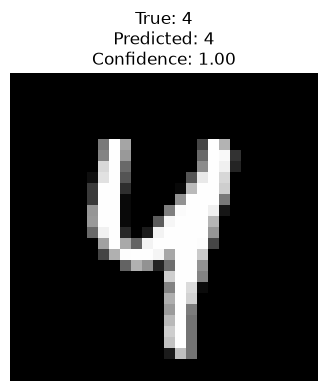

Predicted probabilities:
Digit 0: 0.0000
Digit 1: 0.0000
Digit 2: 0.0000
Digit 3: 0.0000
Digit 4: 1.0000
Digit 5: 0.0000
Digit 6: 0.0000
Digit 7: 0.0000
Digit 8: 0.0000
Digit 9: 0.0000


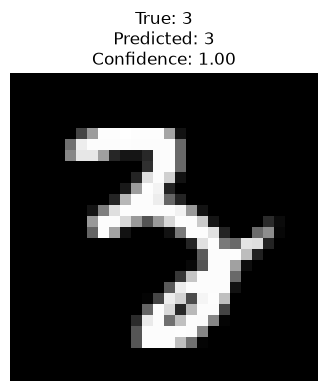

Predicted probabilities:
Digit 0: 0.0000
Digit 1: 0.0000
Digit 2: 0.0000
Digit 3: 1.0000
Digit 4: 0.0000
Digit 5: 0.0000
Digit 6: 0.0000
Digit 7: 0.0000
Digit 8: 0.0000
Digit 9: 0.0000


In [14]:
# Try several examples.
predict_sample(42)
predict_sample(87)


## Key teaching points

1. An MNIST image is a `28 × 28` grayscale image.
2. We normalize the pixels from `[0,255]` to approximately `[-0.5,0.5]`.
3. For an FNN, each image is flattened into 784 numerical input features.
4. `MLPClassifier` learns a nonlinear mapping from those 784 inputs to 10 digit classes.
5. Integer labels are sufficient; one-hot encoding is not required.
6. `predict()` returns predicted class labels.
7. `predict_proba()` returns class probabilities.
8. MNIST is simple enough that a basic FNN can usually achieve high classification accuracy.
9. More complex image datasets often benefit from CNNs because CNNs exploit spatial structure.
